# 가우시안 프로세스 공부 하기
1. Linear

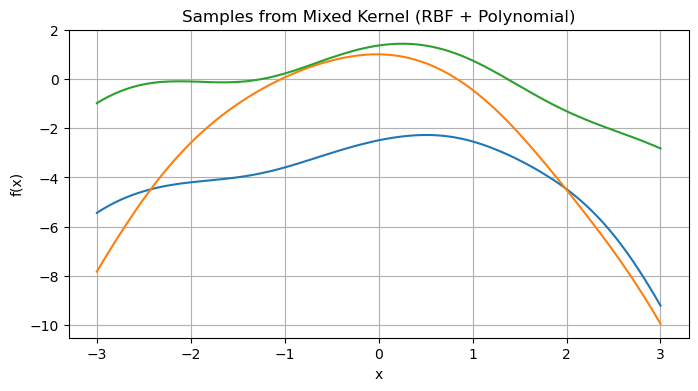

In [98]:
# Re-import after state reset
import numpy as np
import matplotlib.pyplot as plt

# 입력값 정의
X = np.linspace(-3, 3, 100).reshape(-1, 1)

# 다항 커널
def poly_kernel(x1, x2, c, degree=2):
    return (np.dot(x1, x2.T) + c) ** degree

# RBF 커널
def rbf_kernel(x1, x2, length_scale=1.0, variance=1.0):
    sqdist = np.sum(x1**2, 1).reshape(-1, 1) + np.sum(x2**2, 1) - 2 * np.dot(x1, x2.T)
    return variance * np.exp(-0.5 / length_scale**2 * sqdist)

# 혼합 커널: RBF + Polynomial
def mixed_kernel(x1, x2, c=1.0, poly_degree=2, rbf_weight=0.5, poly_weight=100):
    K_rbf = rbf_kernel(x1, x2)
    K_poly = poly_kernel(x1, x2, c, degree=poly_degree)
    return rbf_weight * K_rbf + poly_weight * K_poly

# 커널 행렬 및 샘플링
K_mixed = mixed_kernel(X, X, c=1.0, poly_degree=2, rbf_weight=0.5, poly_weight=0.5)
K_mixed += 1e-6 * np.eye(len(X))
mixed_samples = np.random.multivariate_normal(mean=np.zeros(len(X)), cov=K_mixed, size=3)

# 시각화
plt.figure(figsize=(8, 4))
for sample in mixed_samples:
    plt.plot(X, sample)
plt.title('Samples from Mixed Kernel (RBF + Polynomial)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()


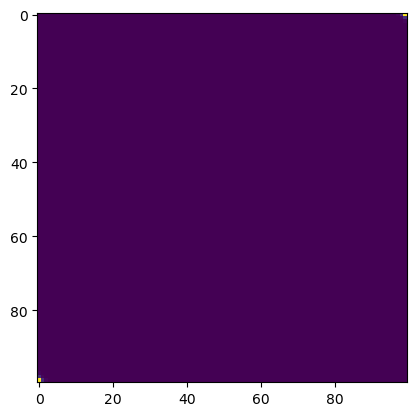

In [26]:
plt.imshow(K)